In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Image Creation Assignment B00158358')

['chest_xray.zip']

In [ ]:
import zipfile

print("Unzipping... please wait")
with zipfile.ZipFile('/content/drive/MyDrive/Image Creation Assignment B00158358/chest_xray.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/chest_xray')
print("Done!")

Unzipping... please wait


In [3]:
!unzip -q '/content/drive/MyDrive/Image Creation Assignment B00158358/chest_xray.zip' -d '/content/chest_xray'
print("Done!")

Done!


In [4]:
import os

base_dir = '/content/chest_xray/chest_xray'

for split in ['train', 'test', 'val']:
    split_path = os.path.join(base_dir, split)
    print(f"\n{split.upper()}:")
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        count = len(os.listdir(class_path))
        print(f"  {class_name}: {count} images")


TRAIN:
  BACTERIAL: 2596 images
  VIRAL: 1363 images
  NORMAL: 1461 images

TEST:
  BACTERIAL: 184 images
  VIRAL: 132 images
  NORMAL: 122 images

VAL:


FileNotFoundError: [Errno 2] No such file or directory: '/content/chest_xray/chest_xray/val'

In [5]:
import tensorflow as tf
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

batch_size = 12
img_width = 128
img_height = 128

train_dir = '/content/chest_xray/chest_xray/train'
test_dir = '/content/chest_xray/chest_xray/test'

# Load datasets
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=123,
    validation_split=0.2,
    subset='both',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed=None,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes:', class_names)
print('Number of classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']
Number of classes: 3


In [6]:
import time

# Build the baseline model
model = tf.keras.models.Sequential([
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy'])

model.summary()

# Train and time it
start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8)

end = time.time()
training_time = end - start
print(f"\nTraining time: {training_time/60:.2f} minutes")

# Evaluate on test set
score = model.evaluate(test_ds)
print(f"Baseline Test Accuracy: {score[1]*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 47s 108ms/step - accuracy: 0.7283 - loss: 0.6433 - val_accuracy: 0.7738 - val_loss: 0.5332
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 36s 98ms/step - accuracy: 0.7894 - loss: 0.5029 - val_accuracy: 0.7692 - val_loss: 0.5398
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.8035 - loss: 0.4645 - val_accuracy: 0.7378 - val_loss: 0.6364
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 31s 85ms/step - accuracy: 0.8176 - loss: 0.4269 - val_accuracy: 0.7858 - val_loss: 0.4998
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 31s 85ms/step - accuracy: 0.8369 - loss: 0.3765 - val_accuracy: 0.7645 - val_loss: 0.5469
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.8644 - loss: 0.3266 - val_accuracy: 0.7784 - val_loss: 0.6412
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.8854 - loss: 0.2734 - val_accuracy: 0.7581 - val_loss: 0.7034
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - accuracy: 0.9101 - loss: 0.2258 - val_acc

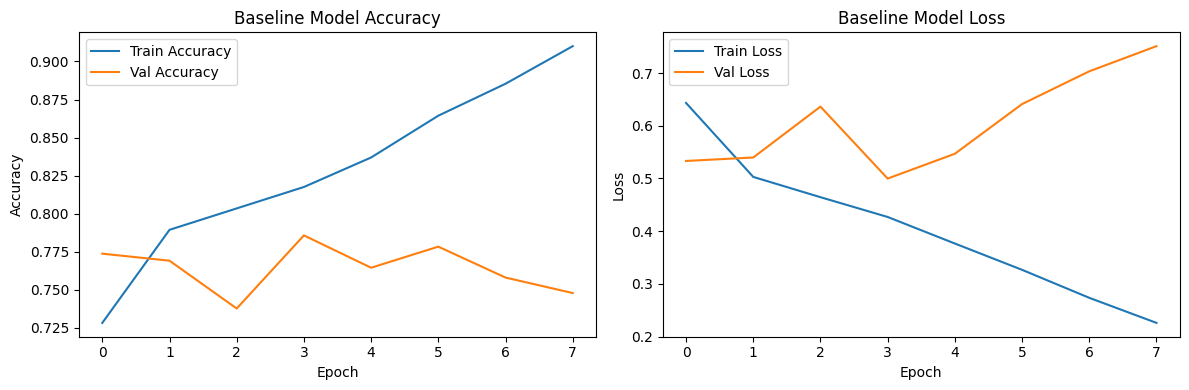

Graph saved!


In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Baseline Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150)
plt.show()
print("Graph saved!")

In [8]:
from keras.layers import GlobalAveragePooling2D
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Rescaling, BatchNormalization

# Data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Improved model
improved_model = tf.keras.models.Sequential([
    Rescaling(1.0/255),
    data_augmentation,
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

improved_model.compile(loss='sparse_categorical_crossentropy',
                       optimizer=Adam(learning_rate=0.0001),
                       metrics=['accuracy'])

improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
start = time.time()

history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            restore_best_weights=True)
    ])

end = time.time()
print(f"\nTraining time: {(end-start)/60:.2f} minutes")

score_improved = improved_model.evaluate(test_ds)
print(f"Improved Model Test Accuracy: {score_improved[1]*100:.2f}%")

Epoch 1/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.6317 - loss: 0.8348 - val_accuracy: 0.3961 - val_loss: 1.2251
Epoch 2/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.6813 - loss: 0.7460 - val_accuracy: 0.4977 - val_loss: 1.1734
Epoch 3/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.7046 - loss: 0.7098 - val_accuracy: 0.3795 - val_loss: 1.6799
Epoch 4/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.7122 - loss: 0.6970 - val_accuracy: 0.3047 - val_loss: 2.3800
Epoch 5/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.7196 - loss: 0.6712 - val_accuracy: 0.5466 - val_loss: 1.1003
Epoch 6/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.7260 - loss: 0.6541 - val_accuracy: 0.4654 - val_loss: 1.3229
Epoch 7/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.7348 - loss: 0.6383 - val_accuracy: 0.6944 - val_loss: 0.6650
Epoch 8/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.7378 - loss: 0.629

In [11]:
# Transfer Learning with MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet')

base_model.trainable = False  # Freeze the pretrained layers

data_augmentation2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

transfer_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    data_augmentation2,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

transfer_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
start = time.time()

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            restore_best_weights=True)
    ])

end = time.time()
print(f"\nTraining time: {(end-start)/60:.2f} minutes")

score_transfer = transfer_model.evaluate(test_ds)
print(f"Transfer Learning Test Accuracy: {score_transfer[1]*100:.2f}%")



Epoch 1/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.6949 - loss: 0.7061 - val_accuracy: 0.7082 - val_loss: 0.6763
Epoch 2/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.7375 - loss: 0.6173 - val_accuracy: 0.6565 - val_loss: 0.7750
Epoch 3/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.7523 - loss: 0.5836 - val_accuracy: 0.6731 - val_loss: 0.8164
Epoch 4/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 46s 104ms/step - accuracy: 0.7613 - loss: 0.5724 - val_accuracy: 0.7525 - val_loss: 0.6391
Epoch 5/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.7650 - loss: 0.5592 - val_accuracy: 0.7415 - val_loss: 0.6380
Epoch 6/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.7638 - loss: 0.5590 - val_accuracy: 0.7276 - val_loss: 0.6917
Epoch 7/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.7689 - loss: 0.5435 - val_accuracy: 0.7313 - val_loss: 0.6715
Epoch 8/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.7788 - loss: 0.5288 

In [13]:
# Unfreeze the last 30 layers of MobileNetV2 for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate
transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

print(f"Trainable layers: {sum([1 for l in base_model.layers if l.trainable])}")

start = time.time()

history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            restore_best_weights=True)
    ])

end = time.time()
print(f"\nTraining time: {(end-start)/60:.2f} minutes")

score_finetune = transfer_model.evaluate(test_ds)
print(f"Fine-tuned Transfer Learning Test Accuracy: {score_finetune[1]*100:.2f}%")

Trainable layers: 30
Epoch 1/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 53s 118ms/step - accuracy: 0.7006 - loss: 0.6772 - val_accuracy: 0.7479 - val_loss: 0.6765
Epoch 2/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.7371 - loss: 0.6138 - val_accuracy: 0.7544 - val_loss: 0.6527
Epoch 3/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step - accuracy: 0.7516 - loss: 0.5886 - val_accuracy: 0.7442 - val_loss: 0.6543
Epoch 4/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.7608 - loss: 0.5756 - val_accuracy: 0.7516 - val_loss: 0.6305
Epoch 5/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.7645 - loss: 0.5541 - val_accuracy: 0.7812 - val_loss: 0.5533
Epoch 6/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 37s 101ms/step - accuracy: 0.7731 - loss: 0.5405 - val_accuracy: 0.7747 - val_loss: 0.5527
Epoch 7/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.7786 - loss: 0.5312 - val_accuracy: 0.7701 - val_loss: 0.5901
Epoch 8/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accura

Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       0.74      0.80      0.77       184
      NORMAL       0.80      0.97      0.88       122
       VIRAL       0.76      0.52      0.62       131

    accuracy                           0.76       437
   macro avg       0.77      0.76      0.75       437
weighted avg       0.76      0.76      0.75       437



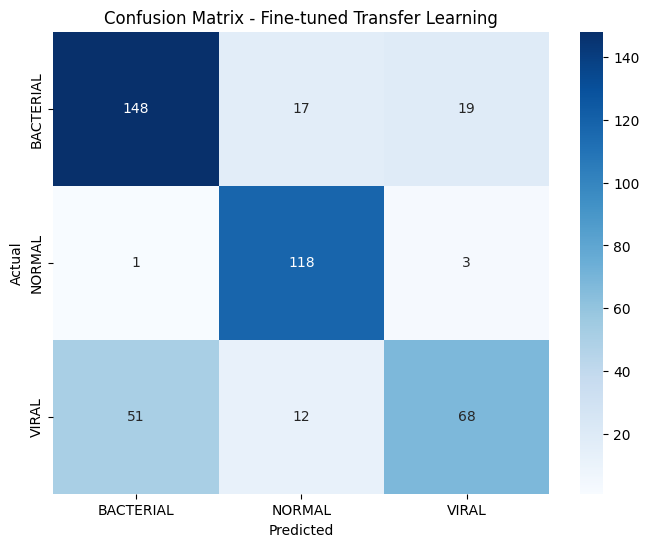

Saved!


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions on test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = transfer_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - Fine-tuned Transfer Learning')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved!")

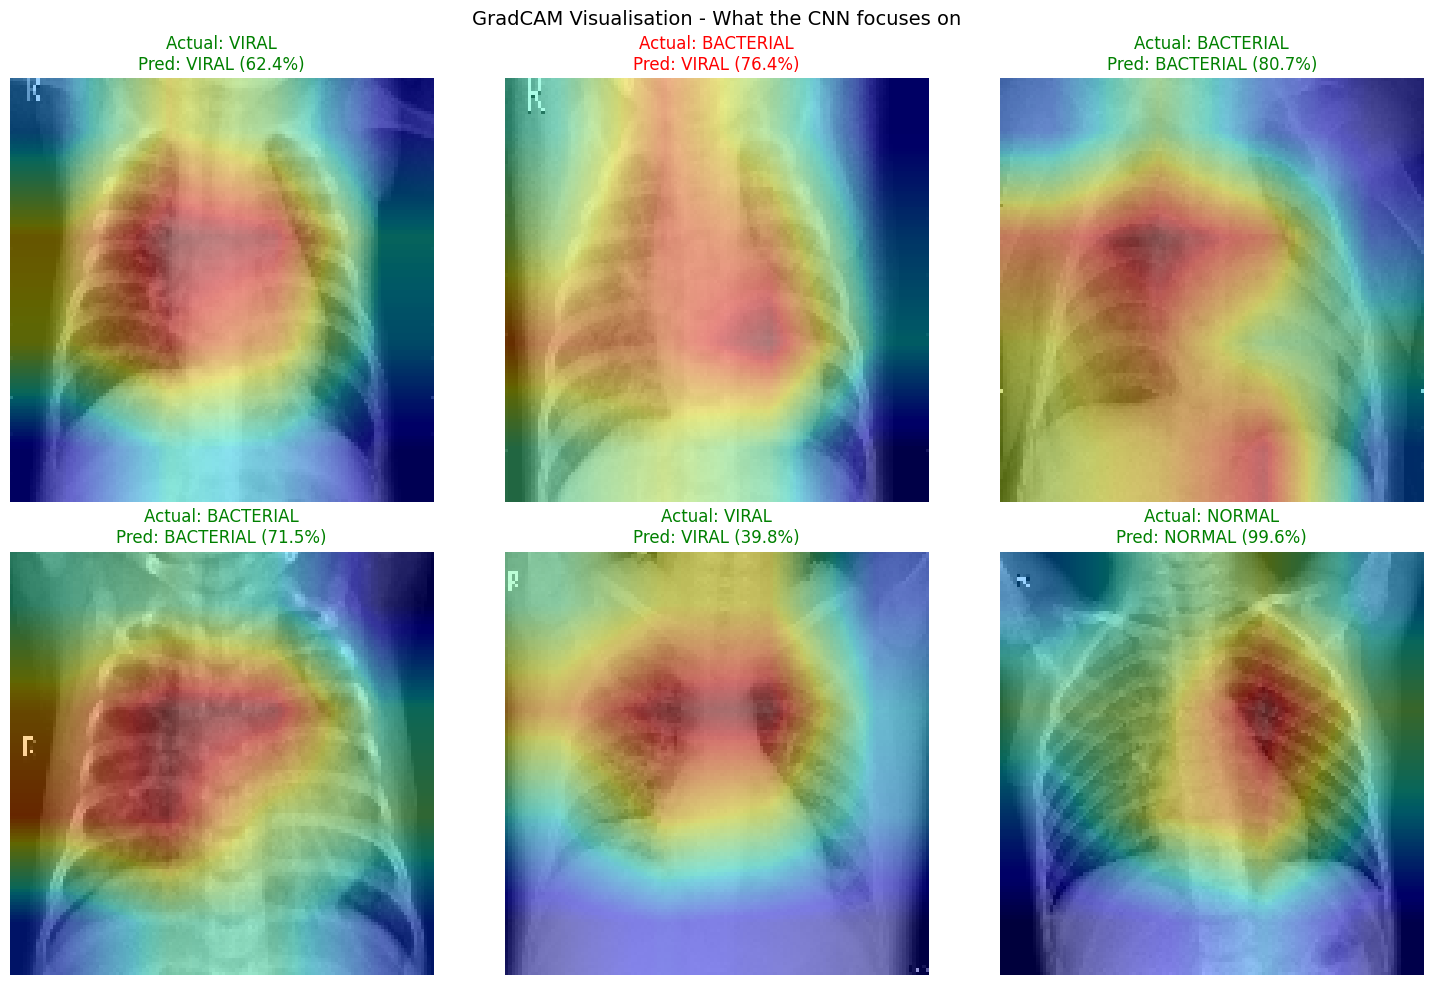

Saved!


In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get a batch of test images
for images, labels in test_ds.take(1):
    test_images = images[:6]
    test_labels = labels[:6]
    break

# Build a model that goes straight to the last conv layer of MobileNetV2
mobilenet = transfer_model.get_layer('mobilenetv2_1.00_128')
last_conv = mobilenet.get_layer('out_relu')

feature_model = tf.keras.Model(
    inputs=mobilenet.input,
    outputs=last_conv.output
)

plt.figure(figsize=(15, 10))

for i in range(6):
    img = test_images[i]
    label = test_labels[i].numpy()

    # Preprocess
    img_preprocessed = (tf.cast(img, tf.float32) / 127.5) - 1.0
    img_batch = tf.expand_dims(img_preprocessed, 0)

    # Get prediction
    pred = transfer_model.predict(tf.expand_dims(img, 0), verbose=0)
    pred_class = np.argmax(pred[0])
    confidence = np.max(pred[0]) * 100

    # Get feature maps
    with tf.GradientTape() as tape:
        feature_maps = feature_model(img_batch)
        tape.watch(feature_maps)
        # Pool the feature maps
        pooled = tf.reduce_mean(feature_maps, axis=[1, 2])

    # Simple heatmap from mean of feature maps
    heatmap = tf.reduce_mean(feature_maps[0], axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Resize and overlay
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (img_height, img_width)).numpy().squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    img_norm = img.numpy().astype(float) / 255.0
    superimposed = heatmap_colored * 0.4 + img_norm * 0.6

    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(superimposed)
    color = 'green' if pred_class == label else 'red'
    plt.title(f'Actual: {class_names[label]}\nPred: {class_names[pred_class]} ({confidence:.1f}%)', color=color)
    plt.axis('off')

plt.suptitle('GradCAM Visualisation - What the CNN focuses on', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150)
plt.show()
print("Saved!")